In [3]:
from pathlib import Path
from PIL import Image, ImageDraw
from collections import Counter
import random
import os

DATASET = Path(r"G:\EcoBotX_YOLO")

CLASS_NAMES = {
    0: "BOTTLE",
    1: "CAN",
    2: "PAPER",
    3: "WRAPPER"
}

print("Dataset:", DATASET)

Dataset: G:\EcoBotX_YOLO


In [4]:
for folder in [
    DATASET / "images" / "train",
    DATASET / "images" / "val",
    DATASET / "images" / "test",
    DATASET / "labels" / "train",
    DATASET / "labels" / "val",
    DATASET / "labels" / "test",
]:
    print(f"{'OK' if folder.exists() else 'MISSING'}  {folder}")

OK  G:\EcoBotX_YOLO\images\train
OK  G:\EcoBotX_YOLO\images\val
OK  G:\EcoBotX_YOLO\images\test
OK  G:\EcoBotX_YOLO\labels\train
OK  G:\EcoBotX_YOLO\labels\val
OK  G:\EcoBotX_YOLO\labels\test


In [5]:
from pathlib import Path
from collections import Counter

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}

def get_images(folder):
    return [
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]


def validate_split(split):

    image_dir = DATASET / "images" / split
    label_dir = DATASET / "labels" / split

    print("\n" + "=" * 70)
    print(f"VALIDATING: {split.upper()}")
    print("=" * 70)

    images = get_images(image_dir)
    labels = list(label_dir.glob("*.txt"))

    print(f"Images : {len(images)}")
    print(f"Labels : {len(labels)}")

    # --------------------------------------------------------
    # Check image -> label
    # --------------------------------------------------------

    missing_labels = []

    for image in images:

        label = label_dir / f"{image.stem}.txt"

        if not label.exists():
            missing_labels.append(image.name)

    # --------------------------------------------------------
    # Check label -> image
    # --------------------------------------------------------

    image_stems = {image.stem for image in images}

    missing_images = []

    for label in labels:

        if label.stem not in image_stems:
            missing_images.append(label.name)

    # --------------------------------------------------------
    # Validate annotations
    # --------------------------------------------------------

    class_counter = Counter()

    invalid_annotations = []
    empty_labels = []

    valid_boxes = 0

    for label in labels:

        try:
            content = label.read_text(
                encoding="utf-8"
            ).strip()
        except Exception as e:

            invalid_annotations.append(
                f"{label.name}: cannot read file: {e}"
            )

            continue

        # Empty annotation = image contains no object
        if not content:

            empty_labels.append(label.name)

            continue

        for line_number, line in enumerate(
            content.splitlines(),
            start=1
        ):

            line = line.strip()

            if not line:
                continue

            values = line.split()

            if len(values) != 5:

                invalid_annotations.append(
                    f"{label.name} line {line_number}: "
                    f"expected 5 values, got {len(values)}"
                )

                continue

            try:

                class_id = int(values[0])

                x = float(values[1])
                y = float(values[2])
                w = float(values[3])
                h = float(values[4])

            except ValueError:

                invalid_annotations.append(
                    f"{label.name} line {line_number}: "
                    "non-numeric value"
                )

                continue

            # Class check
            if class_id not in CLASS_NAMES:

                invalid_annotations.append(
                    f"{label.name} line {line_number}: "
                    f"invalid class ID {class_id}"
                )

                continue

            # Coordinate check
            if not (
                0 <= x <= 1 and
                0 <= y <= 1 and
                0 < w <= 1 and
                0 < h <= 1
            ):

                invalid_annotations.append(
                    f"{label.name} line {line_number}: "
                    f"invalid coordinates "
                    f"{x} {y} {w} {h}"
                )

                continue

            # Boundary check
            if x - w / 2 < 0:
                invalid_annotations.append(
                    f"{label.name} line {line_number}: "
                    "box exceeds left boundary"
                )
                continue

            if x + w / 2 > 1:
                invalid_annotations.append(
                    f"{label.name} line {line_number}: "
                    "box exceeds right boundary"
                )
                continue

            if y - h / 2 < 0:
                invalid_annotations.append(
                    f"{label.name} line {line_number}: "
                    "box exceeds top boundary"
                )
                continue

            if y + h / 2 > 1:
                invalid_annotations.append(
                    f"{label.name} line {line_number}: "
                    "box exceeds bottom boundary"
                )
                continue

            class_counter[class_id] += 1
            valid_boxes += 1

    # --------------------------------------------------------
    # Results
    # --------------------------------------------------------

    print("\nFILE CHECK")

    if missing_labels:
        print(
            f"[WARNING] Images without labels: "
            f"{len(missing_labels)}"
        )

        for x in missing_labels[:10]:
            print("   ", x)

    else:
        print("[OK] Every image has a label.")

    if missing_images:
        print(
            f"[WARNING] Labels without images: "
            f"{len(missing_images)}"
        )

        for x in missing_images[:10]:
            print("   ", x)

    else:
        print("[OK] Every label has an image.")

    print("\nANNOTATION CHECK")

    print(f"Valid boxes       : {valid_boxes}")
    print(f"Empty label files : {len(empty_labels)}")
    print(f"Invalid boxes     : {len(invalid_annotations)}")

    print("\nCLASS DISTRIBUTION")

    for class_id, class_name in CLASS_NAMES.items():

        print(
            f"{class_id} - {class_name:<10}: "
            f"{class_counter[class_id]}"
        )

    if invalid_annotations:

        print("\nINVALID ANNOTATIONS")

        for error in invalid_annotations[:20]:
            print("[ERROR]", error)

        if len(invalid_annotations) > 20:
            print(
                f"... and "
                f"{len(invalid_annotations) - 20} more"
            )

    return {
        "images": images,
        "labels": labels,
        "missing_labels": missing_labels,
        "missing_images": missing_images,
        "invalid_annotations": invalid_annotations,
        "empty_labels": empty_labels,
        "class_counter": class_counter,
        "valid_boxes": valid_boxes
    }

In [6]:
results = {}

for split in ["train", "val", "test"]:

    results[split] = validate_split(split)


VALIDATING: TRAIN
Images : 3563
Labels : 3563

FILE CHECK
[OK] Every image has a label.
[OK] Every label has an image.

ANNOTATION CHECK
Valid boxes       : 2803
Empty label files : 674
Invalid boxes     : 93

CLASS DISTRIBUTION
0 - BOTTLE    : 703
1 - CAN       : 678
2 - PAPER     : 780
3 - WRAPPER   : 642

INVALID ANNOTATIONS
[ERROR] BOTTLE (1028).jpg.6uhfas8o.ingestion-846dcbfcdb-sx8cj.txt line 1: box exceeds left boundary
[ERROR] BOTTLE (212).jpg.6uhfavrm.ingestion-846dcbfcdb-kvjk5.txt line 1: box exceeds right boundary
[ERROR] BOTTLE (306).jpg.6uhfb16r.ingestion-846dcbfcdb-4b7bg.txt line 1: box exceeds right boundary
[ERROR] BOTTLE (313).jpg.6uhfb1c9.ingestion-846dcbfcdb-sx8cj.txt line 1: box exceeds right boundary
[ERROR] BOTTLE (362).jpg.6uhfb26k.ingestion-846dcbfcdb-kvjk5.txt line 1: box exceeds left boundary
[ERROR] BOTTLE (667).jpg.6uhfb78k.ingestion-846dcbfcdb-sx8cj.txt line 1: box exceeds left boundary
[ERROR] BOTTLE (668).jpg.6uhfb72l.ingestion-846dcbfcdb-sx8cj.txt line 1

In [7]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path


def find_invalid_annotations(split):

    image_dir = DATASET / "images" / split
    label_dir = DATASET / "labels" / split

    invalid = []

    for label_path in label_dir.glob("*.txt"):

        content = label_path.read_text(
            encoding="utf-8"
        ).strip()

        if not content:
            continue

        for line_number, line in enumerate(
            content.splitlines(),
            start=1
        ):

            values = line.split()

            if len(values) != 5:
                continue

            try:
                class_id = int(values[0])

                x = float(values[1])
                y = float(values[2])
                w = float(values[3])
                h = float(values[4])

            except ValueError:
                continue

            errors = []

            # Coordinates outside valid range
            if not (0 <= x <= 1):
                errors.append("center_x outside [0,1]")

            if not (0 <= y <= 1):
                errors.append("center_y outside [0,1]")

            if w <= 0 or w > 1:
                errors.append(f"width={w}")

            if h <= 0 or h > 1:
                errors.append(f"height={h}")

            # Box boundary checks
            if x - w / 2 < 0:
                errors.append("left boundary")

            if x + w / 2 > 1:
                errors.append("right boundary")

            if y - h / 2 < 0:
                errors.append("top boundary")

            if y + h / 2 > 1:
                errors.append("bottom boundary")

            if errors:

                image_path = None

                for ext in [
                    ".jpg",
                    ".jpeg",
                    ".png",
                    ".bmp",
                    ".webp"
                ]:

                    candidate = (
                        image_dir /
                        f"{label_path.stem}{ext}"
                    )

                    if candidate.exists():

                        image_path = candidate
                        break

                invalid.append({
                    "split": split,
                    "label": label_path,
                    "image": image_path,
                    "line": line_number,
                    "class_id": class_id,
                    "x": x,
                    "y": y,
                    "w": w,
                    "h": h,
                    "errors": errors
                })

    return invalid

In [8]:
invalid_all = []

for split in ["train", "val", "test"]:

    invalid_split = find_invalid_annotations(split)

    invalid_all.extend(invalid_split)

    print(
        split.upper(),
        ":",
        len(invalid_split),
        "invalid annotations"
    )

print(
    "\nTOTAL INVALID:",
    len(invalid_all)
)

TRAIN : 93 invalid annotations
VAL : 28 invalid annotations
TEST : 26 invalid annotations

TOTAL INVALID: 147


In [9]:
def show_invalid_annotation(item):

    image_path = item["image"]

    if image_path is None:

        print(
            "Could not find corresponding image."
        )

        return

    image = Image.open(
        image_path
    ).convert("RGB")

    width, height = image.size

    x = item["x"] * width
    y = item["y"] * height
    w = item["w"] * width
    h = item["h"] * height

    x1 = x - w / 2
    y1 = y - h / 2
    x2 = x + w / 2
    y2 = y + h / 2

    plt.figure(figsize=(12, 8))

    plt.imshow(image)

    rectangle = plt.Rectangle(
        (x1, y1),
        w,
        h,
        fill=False,
        linewidth=3
    )

    plt.gca().add_patch(rectangle)

    class_name = CLASS_NAMES.get(
        item["class_id"],
        f"UNKNOWN_{item['class_id']}"
    )

    plt.text(
        x1,
        max(0, y1 - 10),
        class_name,
        fontsize=12,
        bbox=dict(
            facecolor="white",
            alpha=0.8
        )
    )

    plt.title(
        f"{item['split'].upper()} | "
        f"{image_path.name}\n"
        f"Errors: {', '.join(item['errors'])}"
    )

    plt.axis("off")

    plt.show()

    print("Image:", image_path)
    print("Label:", item["label"])
    print("Raw YOLO values:")
    print(
        item["class_id"],
        item["x"],
        item["y"],
        item["w"],
        item["h"]
    )

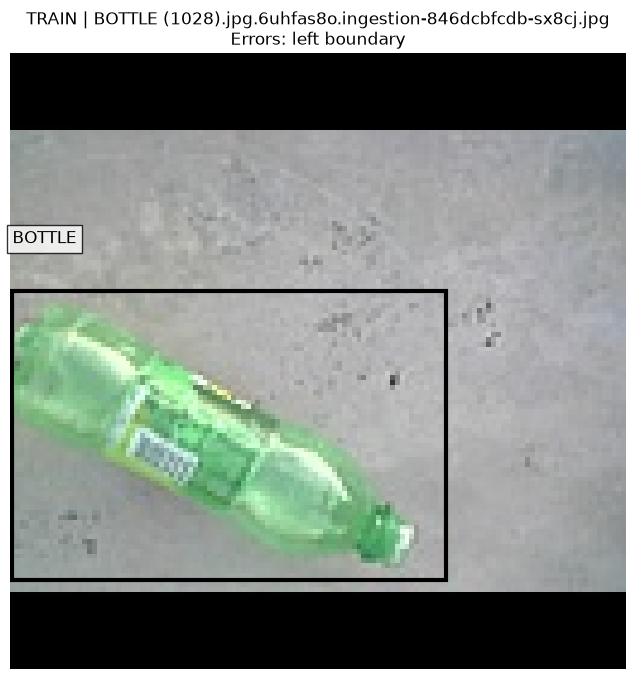

Image: G:\EcoBotX_YOLO\images\train\BOTTLE (1028).jpg.6uhfas8o.ingestion-846dcbfcdb-sx8cj.jpg
Label: G:\EcoBotX_YOLO\labels\train\BOTTLE (1028).jpg.6uhfas8o.ingestion-846dcbfcdb-sx8cj.txt
Raw YOLO values:
0 0.351562 0.617188 0.703125 0.46875


In [10]:
show_invalid_annotation(
    invalid_all[0]
)


========== INVALID 1 / 147 ==========


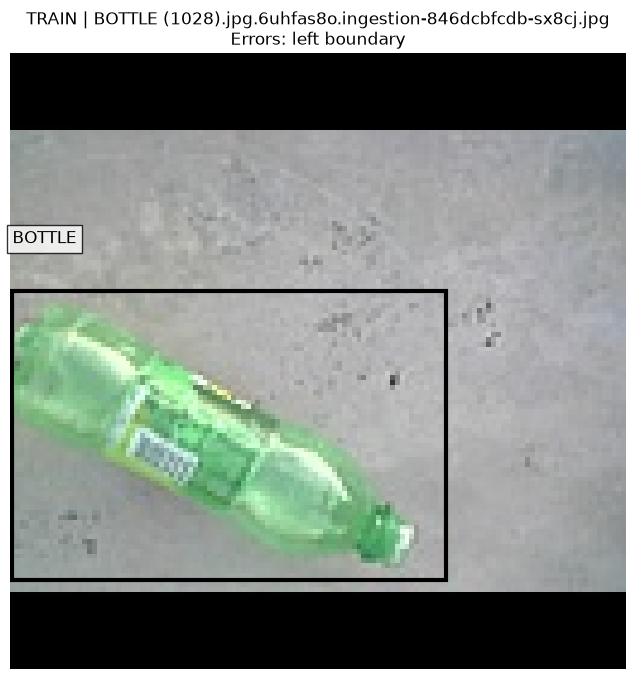

Image: G:\EcoBotX_YOLO\images\train\BOTTLE (1028).jpg.6uhfas8o.ingestion-846dcbfcdb-sx8cj.jpg
Label: G:\EcoBotX_YOLO\labels\train\BOTTLE (1028).jpg.6uhfas8o.ingestion-846dcbfcdb-sx8cj.txt
Raw YOLO values:
0 0.351562 0.617188 0.703125 0.46875

========== INVALID 2 / 147 ==========


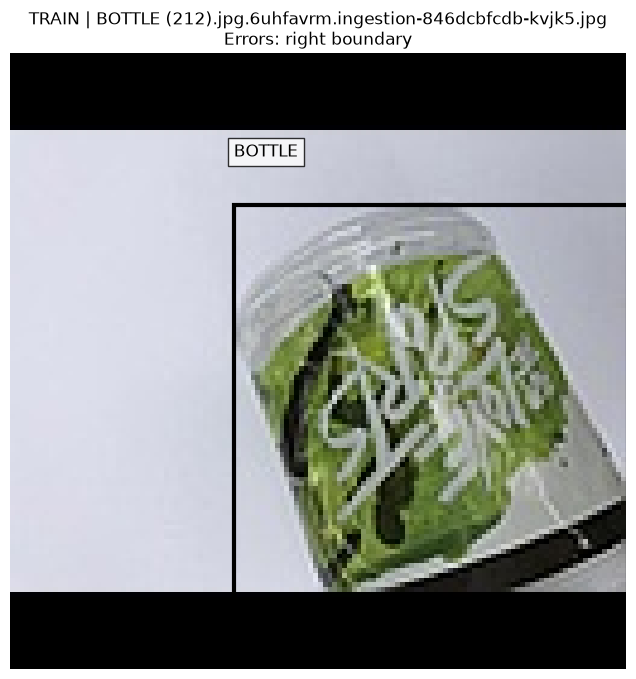

Image: G:\EcoBotX_YOLO\images\train\BOTTLE (212).jpg.6uhfavrm.ingestion-846dcbfcdb-kvjk5.jpg
Label: G:\EcoBotX_YOLO\labels\train\BOTTLE (212).jpg.6uhfavrm.ingestion-846dcbfcdb-kvjk5.txt
Raw YOLO values:
0 0.679688 0.566406 0.640625 0.648438

========== INVALID 3 / 147 ==========


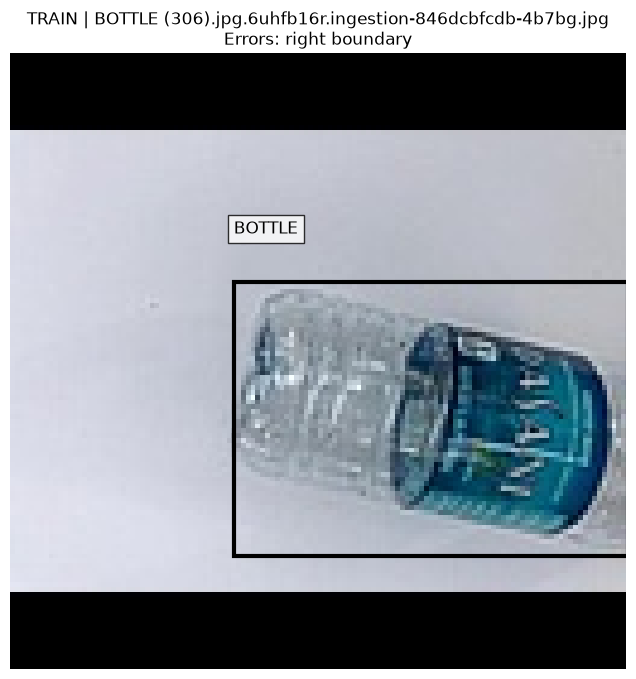

Image: G:\EcoBotX_YOLO\images\train\BOTTLE (306).jpg.6uhfb16r.ingestion-846dcbfcdb-4b7bg.jpg
Label: G:\EcoBotX_YOLO\labels\train\BOTTLE (306).jpg.6uhfb16r.ingestion-846dcbfcdb-4b7bg.txt
Raw YOLO values:
0 0.679688 0.589844 0.640625 0.445312

========== INVALID 4 / 147 ==========


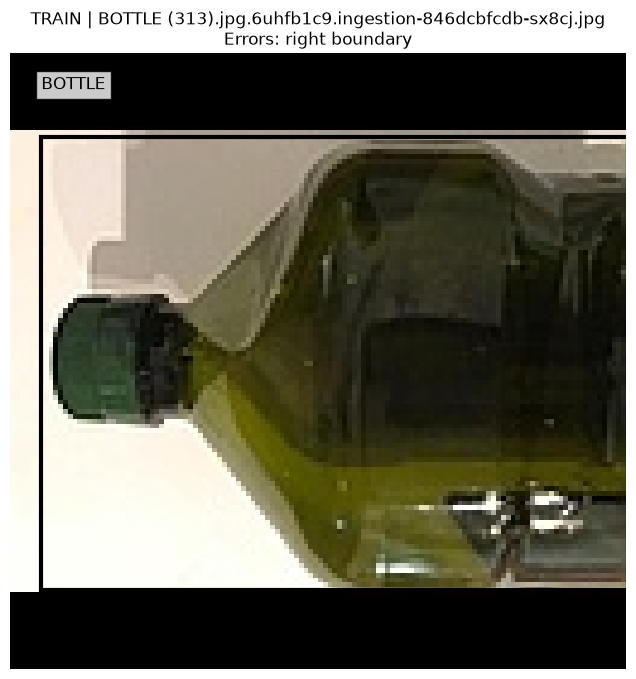

Image: G:\EcoBotX_YOLO\images\train\BOTTLE (313).jpg.6uhfb1c9.ingestion-846dcbfcdb-sx8cj.jpg
Label: G:\EcoBotX_YOLO\labels\train\BOTTLE (313).jpg.6uhfb1c9.ingestion-846dcbfcdb-sx8cj.txt
Raw YOLO values:
0 0.523438 0.5 0.953125 0.734375

========== INVALID 5 / 147 ==========


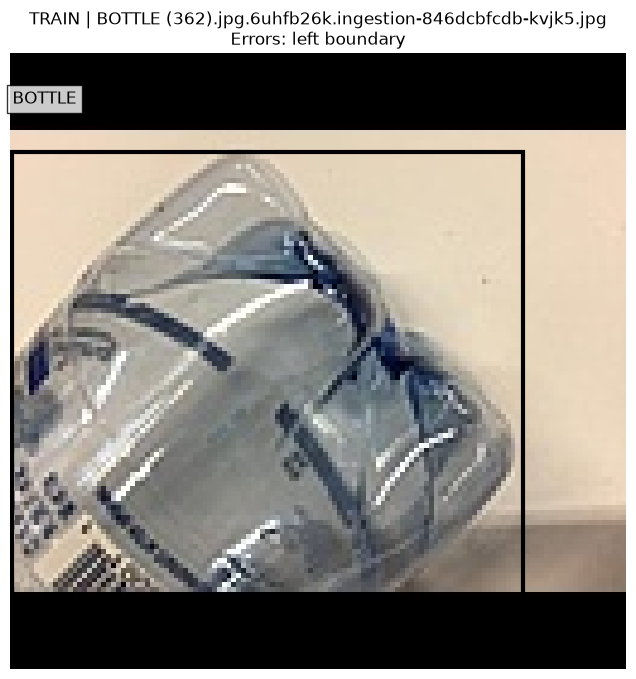

Image: G:\EcoBotX_YOLO\images\train\BOTTLE (362).jpg.6uhfb26k.ingestion-846dcbfcdb-kvjk5.jpg
Label: G:\EcoBotX_YOLO\labels\train\BOTTLE (362).jpg.6uhfb26k.ingestion-846dcbfcdb-kvjk5.txt
Raw YOLO values:
0 0.414062 0.527344 0.828125 0.742188

========== INVALID 6 / 147 ==========


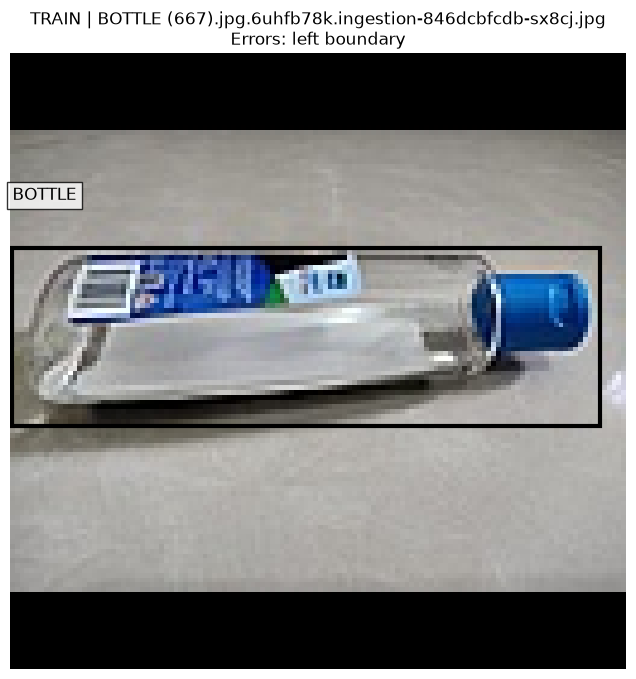

Image: G:\EcoBotX_YOLO\images\train\BOTTLE (667).jpg.6uhfb78k.ingestion-846dcbfcdb-sx8cj.jpg
Label: G:\EcoBotX_YOLO\labels\train\BOTTLE (667).jpg.6uhfb78k.ingestion-846dcbfcdb-sx8cj.txt
Raw YOLO values:
0 0.476562 0.457031 0.953125 0.289062

========== INVALID 7 / 147 ==========


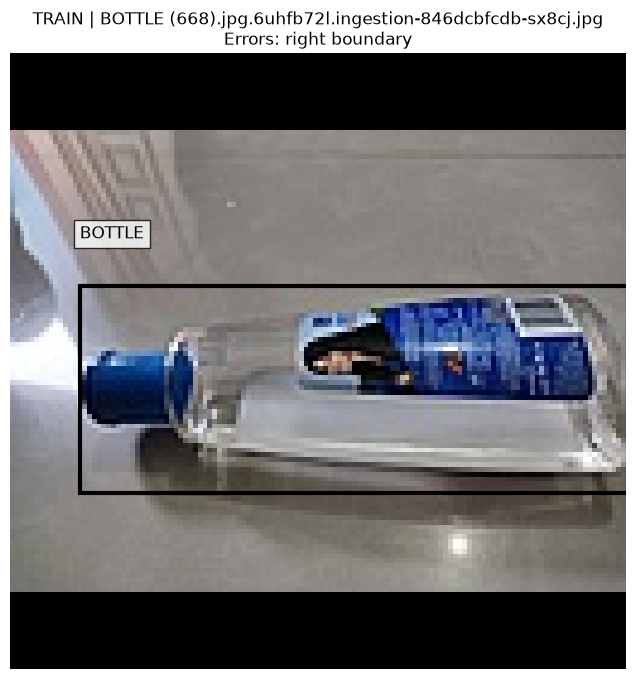

Image: G:\EcoBotX_YOLO\images\train\BOTTLE (668).jpg.6uhfb72l.ingestion-846dcbfcdb-sx8cj.jpg
Label: G:\EcoBotX_YOLO\labels\train\BOTTLE (668).jpg.6uhfb72l.ingestion-846dcbfcdb-sx8cj.txt
Raw YOLO values:
0 0.554688 0.542969 0.890625 0.335938

========== INVALID 8 / 147 ==========


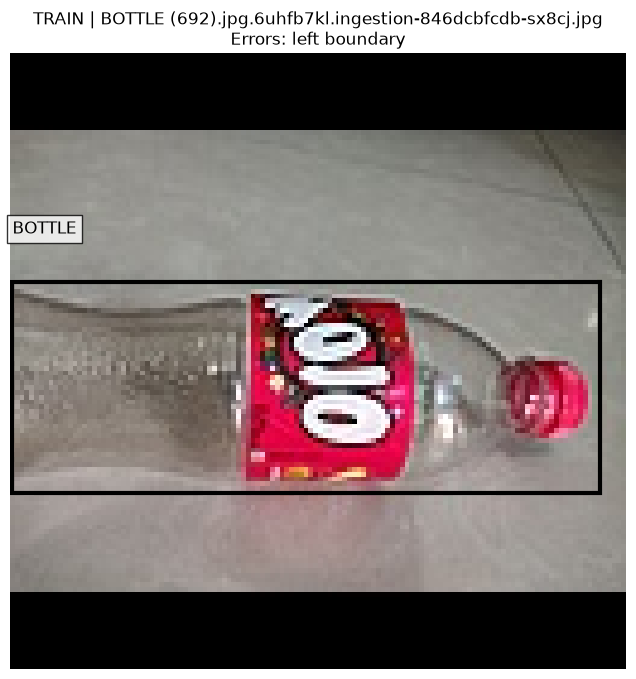

Image: G:\EcoBotX_YOLO\images\train\BOTTLE (692).jpg.6uhfb7kl.ingestion-846dcbfcdb-sx8cj.jpg
Label: G:\EcoBotX_YOLO\labels\train\BOTTLE (692).jpg.6uhfb7kl.ingestion-846dcbfcdb-sx8cj.txt
Raw YOLO values:
0 0.476562 0.539062 0.953125 0.34375

========== INVALID 9 / 147 ==========


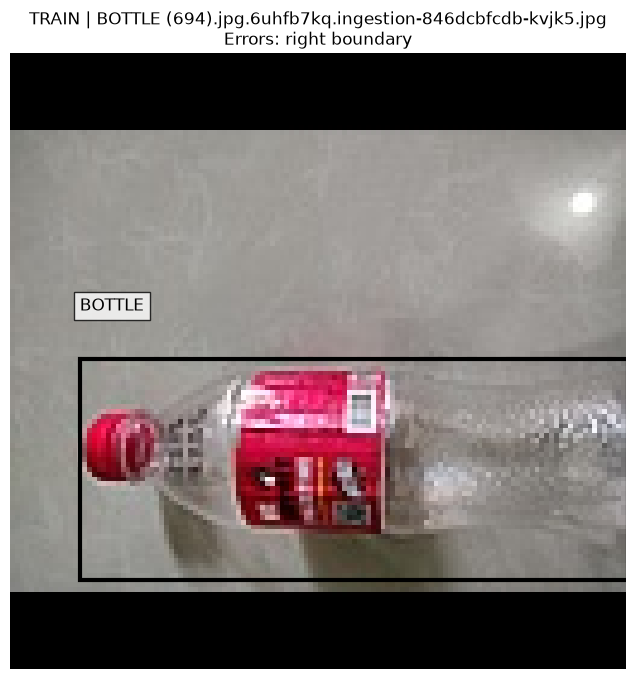

Image: G:\EcoBotX_YOLO\images\train\BOTTLE (694).jpg.6uhfb7kq.ingestion-846dcbfcdb-kvjk5.jpg
Label: G:\EcoBotX_YOLO\labels\train\BOTTLE (694).jpg.6uhfb7kq.ingestion-846dcbfcdb-kvjk5.txt
Raw YOLO values:
0 0.554688 0.671875 0.890625 0.359375

========== INVALID 10 / 147 ==========


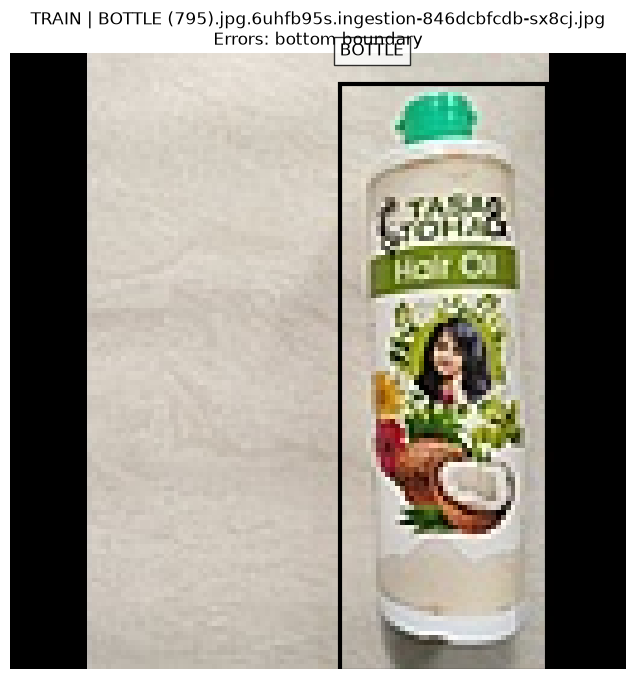

Image: G:\EcoBotX_YOLO\images\train\BOTTLE (795).jpg.6uhfb95s.ingestion-846dcbfcdb-sx8cj.jpg
Label: G:\EcoBotX_YOLO\labels\train\BOTTLE (795).jpg.6uhfb95s.ingestion-846dcbfcdb-sx8cj.txt
Raw YOLO values:
0 0.699219 0.523438 0.335938 0.953125

========== INVALID 11 / 147 ==========


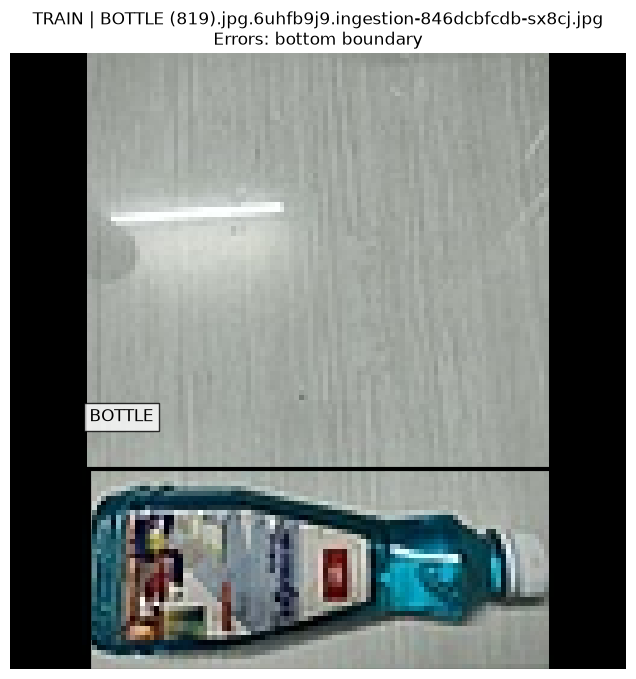

Image: G:\EcoBotX_YOLO\images\train\BOTTLE (819).jpg.6uhfb9j9.ingestion-846dcbfcdb-sx8cj.jpg
Label: G:\EcoBotX_YOLO\labels\train\BOTTLE (819).jpg.6uhfb9j9.ingestion-846dcbfcdb-sx8cj.txt
Raw YOLO values:
0 0.507812 0.835938 0.765625 0.328125

========== INVALID 12 / 147 ==========


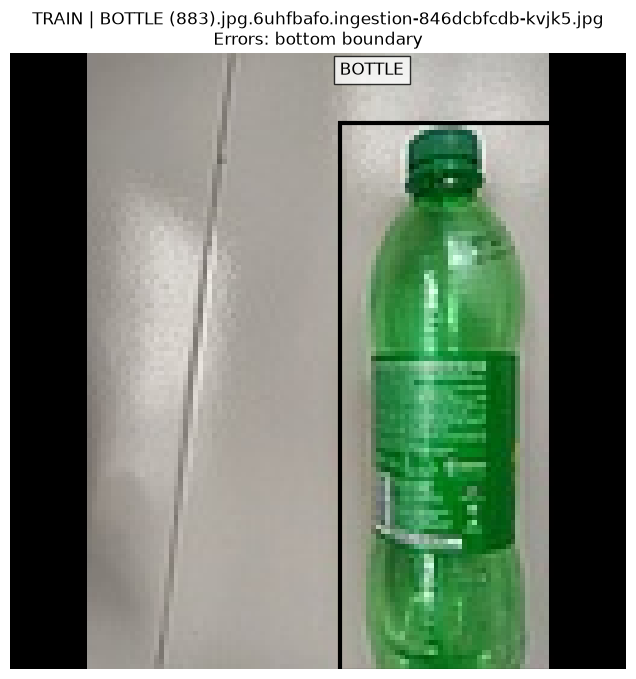

Image: G:\EcoBotX_YOLO\images\train\BOTTLE (883).jpg.6uhfbafo.ingestion-846dcbfcdb-kvjk5.jpg
Label: G:\EcoBotX_YOLO\labels\train\BOTTLE (883).jpg.6uhfbafo.ingestion-846dcbfcdb-kvjk5.txt
Raw YOLO values:
0 0.710938 0.554688 0.359375 0.890625


In [11]:
for i in range(
    min(12, len(invalid_all))
):

    print(
        f"\n========== INVALID {i+1} / "
        f"{len(invalid_all)} =========="
    )

    show_invalid_annotation(
        invalid_all[i]
    )

In [12]:
# ============================================================
# SAFE YOLO BOUNDING-BOX CLIPPING
# ============================================================
# Original dataset:
#     G:\EcoBotX_YOLO
#
# Corrected copy:
#     G:\EcoBotX_YOLO_clipped
#
# IMPORTANT:
# The original dataset is NEVER modified.
# ============================================================

from pathlib import Path
import shutil
import csv
import math


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

SOURCE_DATASET = Path(r"G:\EcoBotX_YOLO")

CORRECTED_DATASET = Path(r"G:\EcoBotX_YOLO_clipped")

# Minimum percentage of the original box area that must remain
# inside the image for automatic clipping.
MIN_RETAINED_AREA = 0.70


# ------------------------------------------------------------
# Make sure source exists
# ------------------------------------------------------------

if not SOURCE_DATASET.exists():

    raise FileNotFoundError(
        f"Source dataset not found:\n{SOURCE_DATASET}"
    )


# ------------------------------------------------------------
# Prevent accidental overwrite
# ------------------------------------------------------------

if CORRECTED_DATASET.exists():

    print("Corrected dataset already exists:")
    print(CORRECTED_DATASET)

    print(
        "\nDelete or rename that folder before running "
        "this cell again."
    )

    raise FileExistsError(
        "Corrected dataset already exists."
    )


# ------------------------------------------------------------
# Copy entire dataset
# ------------------------------------------------------------

print("=" * 70)
print("CREATING CORRECTED DATASET")
print("=" * 70)

print("\nOriginal:")
print(SOURCE_DATASET)

print("\nCorrected copy:")
print(CORRECTED_DATASET)

print("\nCopying dataset...")

shutil.copytree(
    SOURCE_DATASET,
    CORRECTED_DATASET
)

print("Dataset copied successfully.")

print(
    "\nOriginal dataset has NOT been modified."
)


# ------------------------------------------------------------
# Supported image extensions
# ------------------------------------------------------------

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}


# ------------------------------------------------------------
# Statistics
# ------------------------------------------------------------

total_labels = 0
total_boxes = 0

valid_boxes = 0

already_valid = 0

candidate_boxes = 0

clipped_boxes = 0

rejected_boxes = 0

empty_labels = 0

invalid_format = 0

class_counts = {
    0: 0,
    1: 0,
    2: 0,
    3: 0
}


# ------------------------------------------------------------
# Detailed report
# ------------------------------------------------------------

report = []


# ------------------------------------------------------------
# Process each split
# ------------------------------------------------------------

for split in ["train", "val", "test"]:

    print("\n" + "=" * 70)
    print(f"PROCESSING {split.upper()}")
    print("=" * 70)

    image_dir = (
        SOURCE_DATASET
        / "images"
        / split
    )

    source_label_dir = (
        SOURCE_DATASET
        / "labels"
        / split
    )

    corrected_label_dir = (
        CORRECTED_DATASET
        / "labels"
        / split
    )

    corrected_label_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    # --------------------------------------------------------
    # Find images
    # --------------------------------------------------------

    images = [
        p for p in image_dir.iterdir()
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    image_lookup = {
        p.stem: p
        for p in images
    }

    # --------------------------------------------------------
    # Process labels
    # --------------------------------------------------------

    for source_label_path in source_label_dir.glob("*.txt"):

        total_labels += 1

        corrected_label_path = (
            corrected_label_dir
            / source_label_path.name
        )

        image_path = image_lookup.get(
            source_label_path.stem
        )

        # ----------------------------------------------------
        # If corresponding image doesn't exist
        # ----------------------------------------------------

        if image_path is None:

            shutil.copy2(
                source_label_path,
                corrected_label_path
            )

            report.append({
                "split": split,
                "label": source_label_path.name,
                "status": "NO_IMAGE",
                "reason": "Corresponding image not found",
                "original": "",
                "corrected": ""
            })

            continue

        # ----------------------------------------------------
        # Get image dimensions
        # ----------------------------------------------------

        try:

            with Image.open(image_path) as img:

                image_width, image_height = img.size

        except Exception as e:

            shutil.copy2(
                source_label_path,
                corrected_label_path
            )

            report.append({
                "split": split,
                "label": source_label_path.name,
                "status": "IMAGE_ERROR",
                "reason": str(e),
                "original": "",
                "corrected": ""
            })

            continue

        # ----------------------------------------------------
        # Read label
        # ----------------------------------------------------

        content = source_label_path.read_text(
            encoding="utf-8"
        ).strip()

        # Empty label = no object
        if not content:

            empty_labels += 1

            corrected_label_path.write_text(
                "",
                encoding="utf-8"
            )

            continue

        # ----------------------------------------------------
        # Process every annotation
        # ----------------------------------------------------

        new_lines = []

        for line_number, line in enumerate(
            content.splitlines(),
            start=1
        ):

            line = line.strip()

            if not line:
                continue

            values = line.split()

            # ------------------------------------------------
            # Invalid format
            # ------------------------------------------------

            if len(values) != 5:

                invalid_format += 1

                new_lines.append(line)

                report.append({
                    "split": split,
                    "label": source_label_path.name,
                    "status": "REJECTED",
                    "reason": (
                        f"Line {line_number}: "
                        "wrong number of values"
                    ),
                    "original": line,
                    "corrected": line
                })

                continue

            try:

                class_id = int(values[0])

                x_center = float(values[1])
                y_center = float(values[2])

                box_width = float(values[3])
                box_height = float(values[4])

            except ValueError:

                invalid_format += 1

                new_lines.append(line)

                report.append({
                    "split": split,
                    "label": source_label_path.name,
                    "status": "REJECTED",
                    "reason": (
                        f"Line {line_number}: "
                        "non-numeric values"
                    ),
                    "original": line,
                    "corrected": line
                })

                continue

            total_boxes += 1

            # ------------------------------------------------
            # Track class
            # ------------------------------------------------

            if class_id in class_counts:

                class_counts[class_id] += 1

            # ------------------------------------------------
            # Convert normalized YOLO coordinates
            # to image coordinates
            # ------------------------------------------------

            x1 = x_center - box_width / 2
            y1 = y_center - box_height / 2

            x2 = x_center + box_width / 2
            y2 = y_center + box_height / 2

            # ------------------------------------------------
            # Check whether box is already valid
            # ------------------------------------------------

            is_valid = (
                0 <= x1 <= 1 and
                0 <= y1 <= 1 and
                0 <= x2 <= 1 and
                0 <= y2 <= 1 and
                box_width > 0 and
                box_height > 0
            )

            if is_valid:

                valid_boxes += 1
                already_valid += 1

                new_lines.append(line)

                continue

            # ------------------------------------------------
            # Invalid box
            # ------------------------------------------------

            candidate_boxes += 1

            # ------------------------------------------------
            # Calculate whether the center is inside image
            # ------------------------------------------------

            center_inside = (
                0 <= x_center <= 1 and
                0 <= y_center <= 1
            )

            # ------------------------------------------------
            # Calculate original area
            # ------------------------------------------------

            original_width = x2 - x1
            original_height = y2 - y1

            original_area = (
                original_width *
                original_height
            )

            # ------------------------------------------------
            # Calculate intersection with image
            # ------------------------------------------------

            clipped_x1 = max(
                0.0,
                x1
            )

            clipped_y1 = max(
                0.0,
                y1
            )

            clipped_x2 = min(
                1.0,
                x2
            )

            clipped_y2 = min(
                1.0,
                y2
            )

            clipped_width = (
                clipped_x2 -
                clipped_x1
            )

            clipped_height = (
                clipped_y2 -
                clipped_y1
            )

            clipped_area = (
                clipped_width *
                clipped_height
            )

            # ------------------------------------------------
            # Retained area ratio
            # ------------------------------------------------

            if original_area > 0:

                retained_area_ratio = (
                    clipped_area /
                    original_area
                )

            else:

                retained_area_ratio = 0

            # ------------------------------------------------
            # Determine boundary violations
            # ------------------------------------------------

            violations = []

            if x1 < 0:
                violations.append("left")

            if x2 > 1:
                violations.append("right")

            if y1 < 0:
                violations.append("top")

            if y2 > 1:
                violations.append("bottom")

            reason = ", ".join(
                violations
            )

            # ------------------------------------------------
            # SAFETY RULE
            # ------------------------------------------------
            #
            # Automatically clip ONLY if:
            #
            # 1. Class is valid
            # 2. Center is inside image
            # 3. Box has positive intersection
            # 4. At least 70% of original area remains
            #
            # Otherwise leave unchanged for manual review.
            # ------------------------------------------------

            safe_to_clip = (
                class_id in CLASS_NAMES
                and
                center_inside
                and
                clipped_width > 0
                and
                clipped_height > 0
                and
                retained_area_ratio >= MIN_RETAINED_AREA
            )

            if safe_to_clip:

                # --------------------------------------------
                # Convert clipped coordinates back to YOLO
                # --------------------------------------------

                new_x_center = (
                    clipped_x1 +
                    clipped_x2
                ) / 2

                new_y_center = (
                    clipped_y1 +
                    clipped_y2
                ) / 2

                new_width = (
                    clipped_x2 -
                    clipped_x1
                )

                new_height = (
                    clipped_y2 -
                    clipped_y1
                )

                corrected_line = (
                    f"{class_id} "
                    f"{new_x_center:.6f} "
                    f"{new_y_center:.6f} "
                    f"{new_width:.6f} "
                    f"{new_height:.6f}"
                )

                new_lines.append(
                    corrected_line
                )

                clipped_boxes += 1

                valid_boxes += 1

                report.append({
                    "split": split,
                    "label": source_label_path.name,
                    "status": "CLIPPED",
                    "reason": (
                        f"{reason}; "
                        f"retained="
                        f"{retained_area_ratio:.3f}"
                    ),
                    "original": line,
                    "corrected": corrected_line
                })

            else:

                # --------------------------------------------
                # Do NOT modify suspicious annotation
                # --------------------------------------------

                new_lines.append(line)

                rejected_boxes += 1

                report.append({
                    "split": split,
                    "label": source_label_path.name,
                    "status": "REJECTED",
                    "reason": (
                        f"{reason}; "
                        f"center_inside="
                        f"{center_inside}; "
                        f"retained="
                        f"{retained_area_ratio:.3f}"
                    ),
                    "original": line,
                    "corrected": line
                })

        # ----------------------------------------------------
        # Write corrected label
        # ----------------------------------------------------

        corrected_label_path.write_text(
            "\n".join(new_lines),
            encoding="utf-8"
        )


# ============================================================
# Save report
# ============================================================

report_path = (
    CORRECTED_DATASET /
    "annotation_correction_report.csv"
)

with open(
    report_path,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.DictWriter(
        f,
        fieldnames=[
            "split",
            "label",
            "status",
            "reason",
            "original",
            "corrected"
        ]
    )

    writer.writeheader()

    writer.writerows(report)


# ============================================================
# Final summary
# ============================================================

print("\n")
print("=" * 70)
print("CORRECTION SUMMARY")
print("=" * 70)

print(f"Total label files       : {total_labels}")
print(f"Total bounding boxes    : {total_boxes}")
print(f"Already valid boxes     : {already_valid}")
print(f"Invalid candidates      : {candidate_boxes}")
print(f"Automatically clipped   : {clipped_boxes}")
print(f"Rejected for review     : {rejected_boxes}")
print(f"Empty label files       : {empty_labels}")
print(f"Invalid formats         : {invalid_format}")

print("\nClass distribution:")

for class_id, class_name in CLASS_NAMES.items():

    print(
        f"{class_id} - {class_name:<10}: "
        f"{class_counts[class_id]}"
    )

print("\n")
print("=" * 70)

print("CORRECTED DATASET:")
print(CORRECTED_DATASET)

print("\nCORRECTION REPORT:")
print(report_path)

print("=" * 70)

CREATING CORRECTED DATASET

Original:
G:\EcoBotX_YOLO

Corrected copy:
G:\EcoBotX_YOLO_clipped

Copying dataset...
Dataset copied successfully.

Original dataset has NOT been modified.

PROCESSING TRAIN

PROCESSING VAL

PROCESSING TEST


CORRECTION SUMMARY
Total label files       : 5569
Total bounding boxes    : 4509
Already valid boxes     : 4362
Invalid candidates      : 147
Automatically clipped   : 136
Rejected for review     : 11
Empty label files       : 1069
Invalid formats         : 0

Class distribution:
0 - BOTTLE    : 1097
1 - CAN       : 1140
2 - PAPER     : 1255
3 - WRAPPER   : 1017


CORRECTED DATASET:
G:\EcoBotX_YOLO_clipped

CORRECTION REPORT:
G:\EcoBotX_YOLO_clipped\annotation_correction_report.csv


In [13]:
# ============================================================
# SHOW ALL REJECTED ANNOTATIONS
# ============================================================

rejected_items = [
    item
    for item in report
    if item["status"] == "REJECTED"
]

print("=" * 70)
print(f"REJECTED ANNOTATIONS: {len(rejected_items)}")
print("=" * 70)

for i, item in enumerate(rejected_items, start=1):

    print(f"\n[{i}]")
    print("Split    :", item["split"])
    print("Label    :", item["label"])
    print("Reason   :", item["reason"])
    print("Original :", item["original"])

REJECTED ANNOTATIONS: 11

[1]
Split    : train
Label    : CAN (100).jpg.6uhfceon.ingestion-846dcbfcdb-sx8cj.txt
Reason   : right; center_inside=True; retained=0.698
Original : 1 0.917969 0.222656 0.414062 0.429688

[2]
Split    : train
Label    : CAN (893).jpg.6uhfctr6.ingestion-846dcbfcdb-4b7bg.txt
Reason   : right, bottom; center_inside=True; retained=0.618
Original : 1 0.625000 0.699219 1.250000 1.101562

[3]
Split    : train
Label    : CAN (916).jpg.6uhfcu55.ingestion-846dcbfcdb-sx8cj.txt
Reason   : right; center_inside=True; retained=0.635
Original : 1 0.910156 0.675781 0.664062 0.414062

[4]
Split    : train
Label    : CAN (94).jpg.6uhfcuif.ingestion-846dcbfcdb-kvjk5.txt
Reason   : right, bottom; center_inside=False; retained=0.324
Original : 1 0.910156 1.023438 0.398438 0.437500

[5]
Split    : train
Label    : CAN (95).jpg.6uhfcuo9.ingestion-846dcbfcdb-4b7bg.txt
Reason   : bottom; center_inside=True; retained=0.500
Original : 1 0.652344 1.000000 0.351562 0.500000

[6]
Split    


REJECTED 1/11
Split : train
Label : CAN (100).jpg.6uhfceon.ingestion-846dcbfcdb-sx8cj.txt
Reason: right; center_inside=True; retained=0.698
YOLO  : 1 0.917969 0.222656 0.414062 0.429688


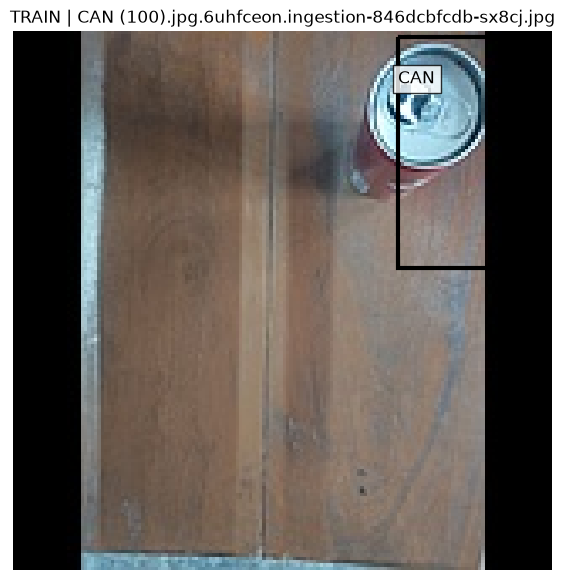


REJECTED 2/11
Split : train
Label : CAN (893).jpg.6uhfctr6.ingestion-846dcbfcdb-4b7bg.txt
Reason: right, bottom; center_inside=True; retained=0.618
YOLO  : 1 0.625000 0.699219 1.250000 1.101562


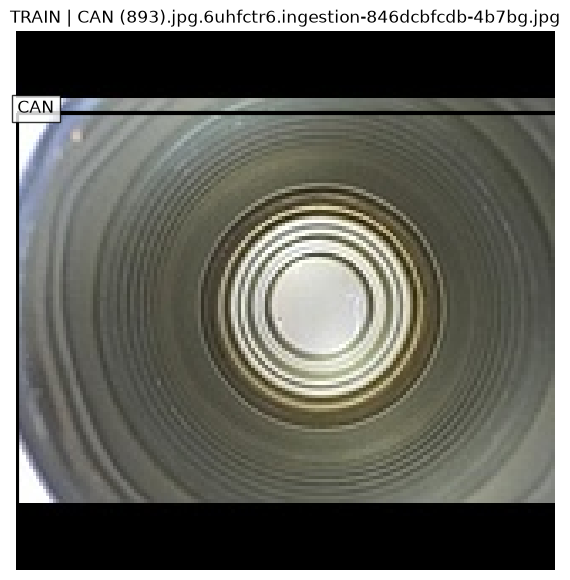


REJECTED 3/11
Split : train
Label : CAN (916).jpg.6uhfcu55.ingestion-846dcbfcdb-sx8cj.txt
Reason: right; center_inside=True; retained=0.635
YOLO  : 1 0.910156 0.675781 0.664062 0.414062


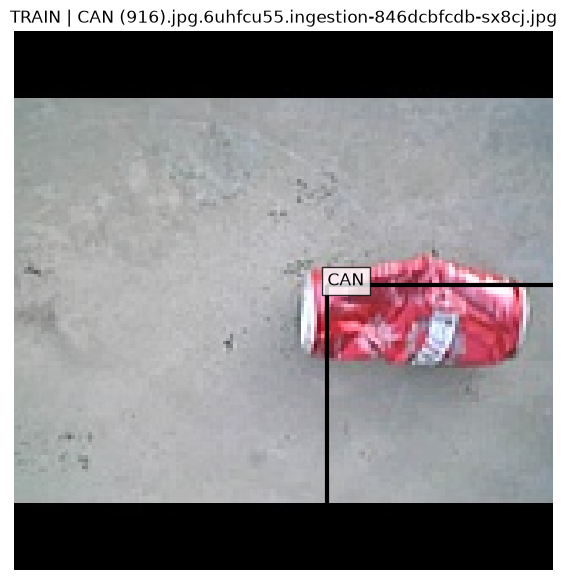


REJECTED 4/11
Split : train
Label : CAN (94).jpg.6uhfcuif.ingestion-846dcbfcdb-kvjk5.txt
Reason: right, bottom; center_inside=False; retained=0.324
YOLO  : 1 0.910156 1.023438 0.398438 0.437500


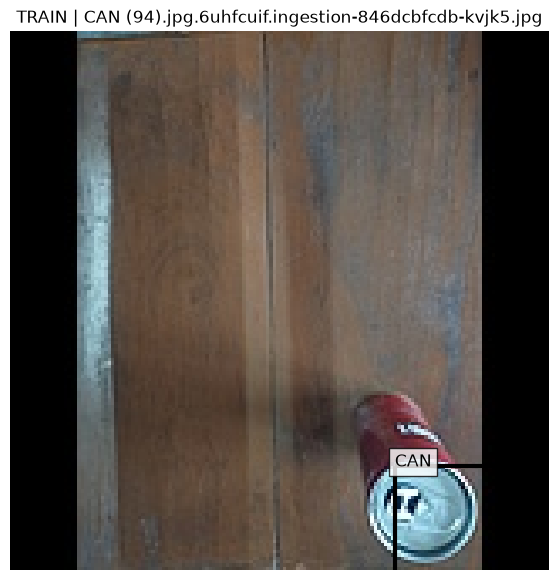


REJECTED 5/11
Split : train
Label : CAN (95).jpg.6uhfcuo9.ingestion-846dcbfcdb-4b7bg.txt
Reason: bottom; center_inside=True; retained=0.500
YOLO  : 1 0.652344 1.000000 0.351562 0.500000


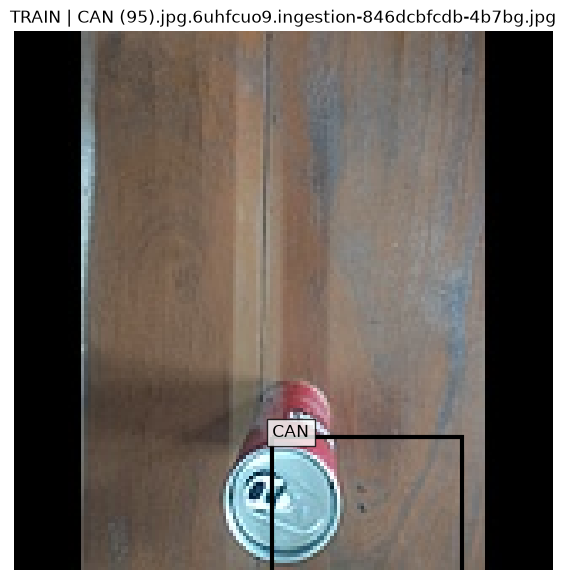


REJECTED 6/11
Split : train
Label : CAN (955).jpg.6uhfcuoh.ingestion-846dcbfcdb-kvjk5.txt
Reason: right; center_inside=True; retained=0.646
YOLO  : 1 0.906250 0.332031 0.640625 0.351562


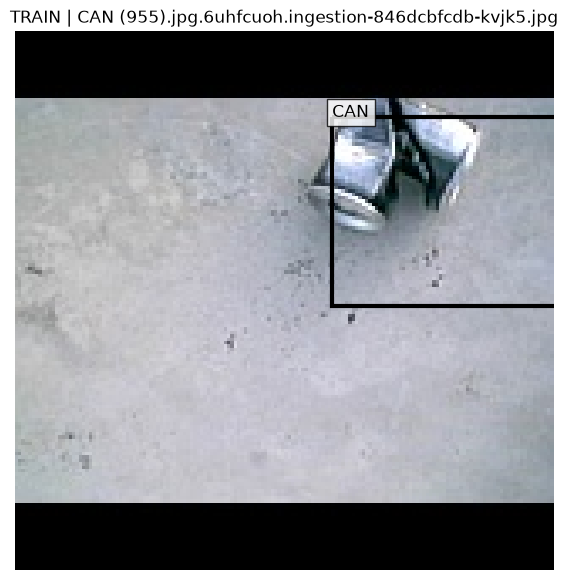


REJECTED 7/11
Split : train
Label : CAN (96).jpg.6uhfcuue.ingestion-846dcbfcdb-sx8cj.txt
Reason: bottom; center_inside=False; retained=0.492
YOLO  : 1 0.304688 1.003906 0.421875 0.492188


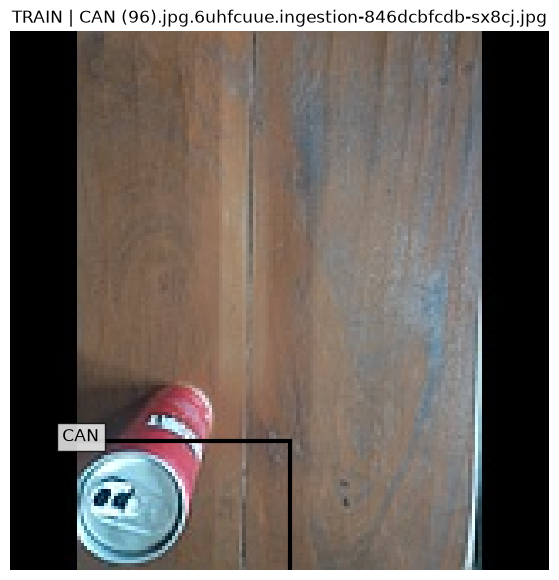


REJECTED 8/11
Split : train
Label : CAN (980).jpg.6uhfcvai.ingestion-846dcbfcdb-kvjk5.txt
Reason: right; center_inside=True; retained=0.683
YOLO  : 1 0.910156 0.386719 0.492188 0.414062


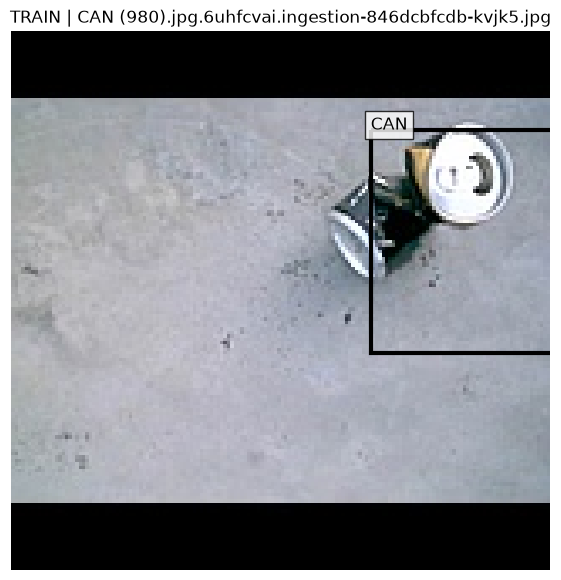


REJECTED 9/11
Split : train
Label : CAN (99).jpg.6uhfcvc0.ingestion-846dcbfcdb-sx8cj.txt
Reason: right; center_inside=True; retained=0.681
YOLO  : 1 0.933594 0.636719 0.367188 0.460938


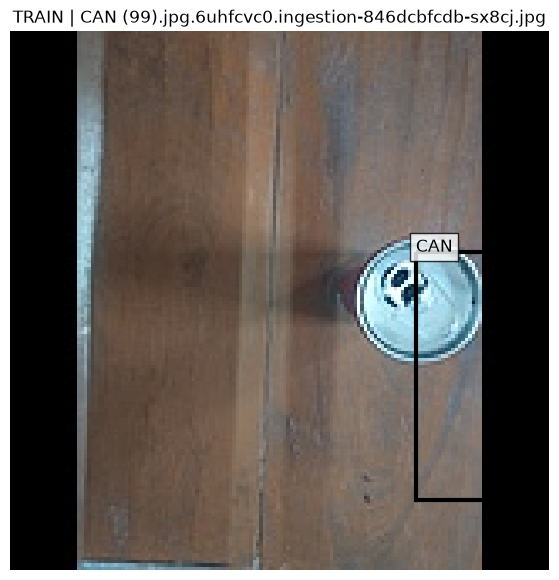


REJECTED 10/11
Split : val
Label : CAN (907).jpg.6uhfcu4m.ingestion-846dcbfcdb-kvjk5.txt
Reason: right, bottom; center_inside=True; retained=0.634
YOLO  : 1 0.824219 0.726562 0.851562 0.687500


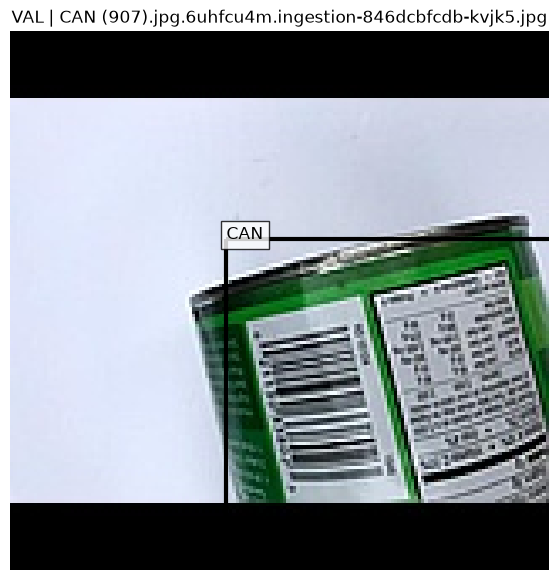


REJECTED 11/11
Split : test
Label : CAN (922).jpg.6uhfcub1.ingestion-846dcbfcdb-4b7bg.txt
Reason: right; center_inside=True; retained=0.535
YOLO  : 1 0.988281 0.460938 0.335938 0.500000


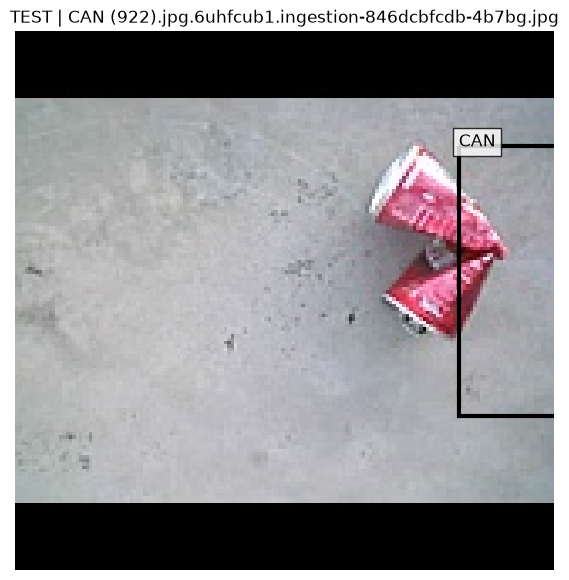

In [14]:
# ============================================================
# VISUALIZE REJECTED ANNOTATIONS
# ============================================================

for i, item in enumerate(rejected_items):

    print("\n" + "=" * 70)
    print(
        f"REJECTED {i + 1}/{len(rejected_items)}"
    )
    print("=" * 70)

    print("Split :", item["split"])
    print("Label :", item["label"])
    print("Reason:", item["reason"])
    print("YOLO  :", item["original"])

    # Find image
    image_dir = (
        SOURCE_DATASET
        / "images"
        / item["split"]
    )

    label_stem = Path(
        item["label"]
    ).stem

    image_path = None

    for ext in [
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".webp"
    ]:

        candidate = (
            image_dir /
            f"{label_stem}{ext}"
        )

        if candidate.exists():

            image_path = candidate
            break

    if image_path is None:

        print("Image not found.")
        continue

    # Load image
    image = Image.open(
        image_path
    ).convert("RGB")

    img_w, img_h = image.size

    # Parse YOLO annotation
    values = item["original"].split()

    class_id = int(values[0])

    x = float(values[1])
    y = float(values[2])
    w = float(values[3])
    h = float(values[4])

    # Convert to pixels
    x1 = (x - w / 2) * img_w
    y1 = (y - h / 2) * img_h

    x2 = (x + w / 2) * img_w
    y2 = (y + h / 2) * img_h

    plt.figure(figsize=(10, 7))

    plt.imshow(image)

    rectangle = plt.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        linewidth=3
    )

    plt.gca().add_patch(
        rectangle
    )

    class_name = CLASS_NAMES.get(
        class_id,
        f"UNKNOWN_{class_id}"
    )

    plt.text(
        max(0, x1),
        max(15, y1),
        class_name,
        fontsize=12,
        bbox=dict(
            facecolor="white",
            alpha=0.8
        )
    )

    plt.title(
        f"{item['split'].upper()} | "
        f"{image_path.name}"
    )

    plt.axis("off")

    plt.show()

In [15]:
# ============================================================
# CREATE FINAL YOLO DATASET
# ============================================================
# Source:
#     G:\EcoBotX_YOLO_clipped
#
# Final:
#     G:\EcoBotX_YOLO_final
#
# The 11 rejected images will be completely excluded.
# ============================================================

from pathlib import Path
import shutil

SOURCE_FINAL = Path(r"G:\EcoBotX_YOLO_clipped")
FINAL_DATASET = Path(r"G:\EcoBotX_YOLO_final")

if not SOURCE_FINAL.exists():
    raise FileNotFoundError(
        f"Dataset not found:\n{SOURCE_FINAL}"
    )

if FINAL_DATASET.exists():
    raise FileExistsError(
        f"Final dataset already exists:\n{FINAL_DATASET}\n"
        "Delete it first if you want to recreate it."
    )

print("Copying corrected dataset...")

shutil.copytree(
    SOURCE_FINAL,
    FINAL_DATASET
)

print("Dataset copied.")
print("Original corrected dataset remains untouched.")


# ============================================================
# Remove the 11 rejected images + labels
# ============================================================

removed = []

for item in rejected_items:

    split = item["split"]
    label_name = item["label"]

    label_path = (
        FINAL_DATASET
        / "labels"
        / split
        / label_name
    )

    image_stem = Path(label_name).stem

    image_dir = (
        FINAL_DATASET
        / "images"
        / split
    )

    image_path = None

    for ext in [
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".webp"
    ]:

        candidate = (
            image_dir /
            f"{image_stem}{ext}"
        )

        if candidate.exists():
            image_path = candidate
            break

    # Remove label
    if label_path.exists():
        label_path.unlink()

    # Remove image
    if image_path is not None:
        image_path.unlink()

    removed.append(
        (split, image_stem)
    )

    print(
        f"Removed: {split}/{image_stem}"
    )


print("\n" + "=" * 70)
print("FINAL DATASET CREATED")
print("=" * 70)

print(
    f"Location:\n{FINAL_DATASET}"
)

print(
    f"\nExcluded images: {len(removed)}"
)

print("=" * 70)

Copying corrected dataset...
Dataset copied.
Original corrected dataset remains untouched.
Removed: train/CAN (100).jpg.6uhfceon.ingestion-846dcbfcdb-sx8cj
Removed: train/CAN (893).jpg.6uhfctr6.ingestion-846dcbfcdb-4b7bg
Removed: train/CAN (916).jpg.6uhfcu55.ingestion-846dcbfcdb-sx8cj
Removed: train/CAN (94).jpg.6uhfcuif.ingestion-846dcbfcdb-kvjk5
Removed: train/CAN (95).jpg.6uhfcuo9.ingestion-846dcbfcdb-4b7bg
Removed: train/CAN (955).jpg.6uhfcuoh.ingestion-846dcbfcdb-kvjk5
Removed: train/CAN (96).jpg.6uhfcuue.ingestion-846dcbfcdb-sx8cj
Removed: train/CAN (980).jpg.6uhfcvai.ingestion-846dcbfcdb-kvjk5
Removed: train/CAN (99).jpg.6uhfcvc0.ingestion-846dcbfcdb-sx8cj
Removed: val/CAN (907).jpg.6uhfcu4m.ingestion-846dcbfcdb-kvjk5
Removed: test/CAN (922).jpg.6uhfcub1.ingestion-846dcbfcdb-4b7bg

FINAL DATASET CREATED
Location:
G:\EcoBotX_YOLO_final

Excluded images: 11


In [16]:
# ============================================================
# CREATE FINAL DATASET YAML
# ============================================================

yaml_content = f"""path: {FINAL_DATASET}

train: images/train
val: images/val
test: images/test

names:
  0: BOTTLE
  1: CAN
  2: PAPER
  3: WRAPPER
"""

yaml_path = FINAL_DATASET / "dataset.yaml"

yaml_path.write_text(
    yaml_content,
    encoding="utf-8"
)

print("dataset.yaml created:")
print(yaml_path)

print("\nContents:")
print(yaml_content)

dataset.yaml created:
G:\EcoBotX_YOLO_final\dataset.yaml

Contents:
path: G:\EcoBotX_YOLO_final

train: images/train
val: images/val
test: images/test

names:
  0: BOTTLE
  1: CAN
  2: PAPER
  3: WRAPPER



In [17]:
# ============================================================
# FINAL VALIDATION
# ============================================================

from PIL import Image

def validate_final_split(split):

    image_dir = (
        FINAL_DATASET
        / "images"
        / split
    )

    label_dir = (
        FINAL_DATASET
        / "labels"
        / split
    )

    images = [
        p for p in image_dir.iterdir()
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    labels = list(
        label_dir.glob("*.txt")
    )

    image_stems = {
        p.stem for p in images
    }

    label_stems = {
        p.stem for p in labels
    }

    valid = 0
    empty = 0
    invalid = 0

    class_counts = {
        0: 0,
        1: 0,
        2: 0,
        3: 0
    }

    invalid_details = []

    for label_path in labels:

        content = label_path.read_text(
            encoding="utf-8"
        ).strip()

        if not content:

            empty += 1
            continue

        for line_number, line in enumerate(
            content.splitlines(),
            start=1
        ):

            values = line.split()

            if len(values) != 5:

                invalid += 1

                invalid_details.append(
                    (
                        label_path.name,
                        line_number,
                        "wrong number of values"
                    )
                )

                continue

            try:

                class_id = int(values[0])

                x = float(values[1])
                y = float(values[2])
                w = float(values[3])
                h = float(values[4])

            except ValueError:

                invalid += 1

                invalid_details.append(
                    (
                        label_path.name,
                        line_number,
                        "non-numeric values"
                    )
                )

                continue

            x1 = x - w / 2
            y1 = y - h / 2
            x2 = x + w / 2
            y2 = y + h / 2

            good = (
                class_id in CLASS_NAMES
                and
                0 <= x1 <= 1
                and
                0 <= y1 <= 1
                and
                0 <= x2 <= 1
                and
                0 <= y2 <= 1
                and
                w > 0
                and
                h > 0
            )

            if good:

                valid += 1

                class_counts[class_id] += 1

            else:

                invalid += 1

                invalid_details.append(
                    (
                        label_path.name,
                        line_number,
                        line
                    )
                )

    return {
        "images": len(images),
        "labels": len(labels),
        "valid": valid,
        "empty": empty,
        "invalid": invalid,
        "class_counts": class_counts,
        "missing_labels": image_stems - label_stems,
        "missing_images": label_stems - image_stems,
        "invalid_details": invalid_details
    }


final_results = {}

for split in [
    "train",
    "val",
    "test"
]:

    result = validate_final_split(split)

    final_results[split] = result

    print("\n" + "=" * 70)
    print(f"FINAL VALIDATION: {split.upper()}")
    print("=" * 70)

    print(
        "Images          :",
        result["images"]
    )

    print(
        "Labels          :",
        result["labels"]
    )

    print(
        "Valid boxes     :",
        result["valid"]
    )

    print(
        "Empty labels    :",
        result["empty"]
    )

    print(
        "Invalid boxes   :",
        result["invalid"]
    )

    print(
        "Missing labels  :",
        len(result["missing_labels"])
    )

    print(
        "Missing images  :",
        len(result["missing_images"])
    )

    print("\nClasses:")

    for class_id, class_name in CLASS_NAMES.items():

        print(
            f"{class_id} - "
            f"{class_name:<10}: "
            f"{result['class_counts'][class_id]}"
        )


FINAL VALIDATION: TRAIN
Images          : 3554
Labels          : 3554
Valid boxes     : 2840
Empty labels    : 674
Invalid boxes   : 47
Missing labels  : 0
Missing images  : 0

Classes:
0 - BOTTLE    : 708
1 - CAN       : 700
2 - PAPER     : 790
3 - WRAPPER   : 642

FINAL VALIDATION: VAL
Images          : 890
Labels          : 890
Valid boxes     : 704
Empty labels    : 179
Invalid boxes   : 9
Missing labels  : 0
Missing images  : 0

Classes:
0 - BOTTLE    : 162
1 - CAN       : 188
2 - PAPER     : 194
3 - WRAPPER   : 160

FINAL VALIDATION: TEST
Images          : 1114
Labels          : 1114
Valid boxes     : 884
Empty labels    : 216
Invalid boxes   : 14
Missing labels  : 0
Missing images  : 0

Classes:
0 - BOTTLE    : 217
1 - CAN       : 225
2 - PAPER     : 246
3 - WRAPPER   : 196


In [18]:
# ============================================================
# BUILD CLEAN FINAL DATASET FROM ORIGINAL
# ============================================================

from pathlib import Path
from PIL import Image
import shutil
import csv

ORIGINAL_DATASET = Path(r"G:\EcoBotX_YOLO")
CLEAN_DATASET = Path(r"G:\EcoBotX_YOLO_FINAL")

if CLEAN_DATASET.exists():
    raise FileExistsError(
        f"Dataset already exists:\n{CLEAN_DATASET}\n\n"
        "Delete it manually before running this cell again."
    )

CLEAN_DATASET.mkdir(parents=True)

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}

CLASS_NAMES = {
    0: "BOTTLE",
    1: "CAN",
    2: "PAPER",
    3: "WRAPPER"
}

# ------------------------------------------------------------
# Statistics
# ------------------------------------------------------------

stats = {
    "train": {
        "images": 0,
        "valid": 0,
        "clipped": 0,
        "skipped": 0,
        "empty": 0
    },
    "val": {
        "images": 0,
        "valid": 0,
        "clipped": 0,
        "skipped": 0,
        "empty": 0
    },
    "test": {
        "images": 0,
        "valid": 0,
        "clipped": 0,
        "skipped": 0,
        "empty": 0
    }
}

correction_report = []


# ============================================================
# PROCESS EACH SPLIT
# ============================================================

for split in ["train", "val", "test"]:

    print("\n" + "=" * 70)
    print(f"PROCESSING {split.upper()}")
    print("=" * 70)

    source_images = (
        ORIGINAL_DATASET /
        "images" /
        split
    )

    source_labels = (
        ORIGINAL_DATASET /
        "labels" /
        split
    )

    target_images = (
        CLEAN_DATASET /
        "images" /
        split
    )

    target_labels = (
        CLEAN_DATASET /
        "labels" /
        split
    )

    target_images.mkdir(
        parents=True,
        exist_ok=True
    )

    target_labels.mkdir(
        parents=True,
        exist_ok=True
    )

    images = [
        p for p in source_images.iterdir()
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    for image_path in images:

        stats[split]["images"] += 1

        label_path = (
            source_labels /
            f"{image_path.stem}.txt"
        )

        target_image = (
            target_images /
            image_path.name
        )

        target_label = (
            target_labels /
            f"{image_path.stem}.txt"
        )

        # ----------------------------------------------------
        # Copy image
        # ----------------------------------------------------

        shutil.copy2(
            image_path,
            target_image
        )

        # ----------------------------------------------------
        # Missing label
        # ----------------------------------------------------

        if not label_path.exists():

            target_label.write_text(
                "",
                encoding="utf-8"
            )

            stats[split]["empty"] += 1

            continue

        # ----------------------------------------------------
        # Read label
        # ----------------------------------------------------

        content = label_path.read_text(
            encoding="utf-8"
        ).strip()

        # Empty label = no object
        if not content:

            target_label.write_text(
                "",
                encoding="utf-8"
            )

            stats[split]["empty"] += 1

            continue

        # ----------------------------------------------------
        # Image dimensions
        # ----------------------------------------------------

        try:

            with Image.open(image_path) as img:

                img_w, img_h = img.size

        except Exception:

            print(
                "Could not read image:",
                image_path.name
            )

            target_label.write_text(
                "",
                encoding="utf-8"
            )

            continue

        new_lines = []

        # ----------------------------------------------------
        # Process every annotation
        # ----------------------------------------------------

        for line_number, line in enumerate(
            content.splitlines(),
            start=1
        ):

            values = line.split()

            # ------------------------------------------------
            # Bad format → skip
            # ------------------------------------------------

            if len(values) != 5:

                stats[split]["skipped"] += 1

                correction_report.append({
                    "split": split,
                    "image": image_path.name,
                    "line": line_number,
                    "status": "SKIPPED",
                    "reason": "Wrong number of values",
                    "original": line,
                    "corrected": ""
                })

                continue

            try:

                class_id = int(values[0])

                x = float(values[1])
                y = float(values[2])
                w = float(values[3])
                h = float(values[4])

            except ValueError:

                stats[split]["skipped"] += 1

                correction_report.append({
                    "split": split,
                    "image": image_path.name,
                    "line": line_number,
                    "status": "SKIPPED",
                    "reason": "Non-numeric annotation",
                    "original": line,
                    "corrected": ""
                })

                continue

            # ------------------------------------------------
            # Invalid class
            # ------------------------------------------------

            if class_id not in CLASS_NAMES:

                stats[split]["skipped"] += 1

                correction_report.append({
                    "split": split,
                    "image": image_path.name,
                    "line": line_number,
                    "status": "SKIPPED",
                    "reason": "Invalid class ID",
                    "original": line,
                    "corrected": ""
                })

                continue

            # ------------------------------------------------
            # Reject NaN / infinity
            # ------------------------------------------------

            import math

            if not all(
                math.isfinite(v)
                for v in [x, y, w, h]
            ):

                stats[split]["skipped"] += 1

                correction_report.append({
                    "split": split,
                    "image": image_path.name,
                    "line": line_number,
                    "status": "SKIPPED",
                    "reason": "NaN or infinity",
                    "original": line,
                    "corrected": ""
                })

                continue

            # ------------------------------------------------
            # Original YOLO box
            # ------------------------------------------------

            x1 = x - w / 2
            y1 = y - h / 2

            x2 = x + w / 2
            y2 = y + h / 2

            # ------------------------------------------------
            # Completely impossible box
            #
            # If the box doesn't intersect the image at all,
            # skip it.
            # ------------------------------------------------

            if (
                x2 <= 0 or
                x1 >= 1 or
                y2 <= 0 or
                y1 >= 1 or
                w <= 0 or
                h <= 0
            ):

                stats[split]["skipped"] += 1

                correction_report.append({
                    "split": split,
                    "image": image_path.name,
                    "line": line_number,
                    "status": "SKIPPED",
                    "reason": "Box has no valid image intersection",
                    "original": line,
                    "corrected": ""
                })

                continue

            # ------------------------------------------------
            # Clip to image boundary
            # ------------------------------------------------

            cx1 = max(
                0.0,
                min(1.0, x1)
            )

            cy1 = max(
                0.0,
                min(1.0, y1)
            )

            cx2 = max(
                0.0,
                min(1.0, x2)
            )

            cy2 = max(
                0.0,
                min(1.0, y2)
            )

            # ------------------------------------------------
            # Make sure clipped box is valid
            # ------------------------------------------------

            if (
                cx2 <= cx1 or
                cy2 <= cy1
            ):

                stats[split]["skipped"] += 1

                correction_report.append({
                    "split": split,
                    "image": image_path.name,
                    "line": line_number,
                    "status": "SKIPPED",
                    "reason": "Zero-area after clipping",
                    "original": line,
                    "corrected": ""
                })

                continue

            # ------------------------------------------------
            # Convert clipped box back to YOLO format
            # ------------------------------------------------

            new_x = (
                cx1 + cx2
            ) / 2

            new_y = (
                cy1 + cy2
            ) / 2

            new_w = (
                cx2 - cx1
            )

            new_h = (
                cy2 - cy1
            )

            # ------------------------------------------------
            # Final numerical safety clamp
            # ------------------------------------------------

            new_x = max(
                0.0,
                min(1.0, new_x)
            )

            new_y = max(
                0.0,
                min(1.0, new_y)
            )

            new_w = max(
                0.000001,
                min(1.0, new_w)
            )

            new_h = max(
                0.000001,
                min(1.0, new_h)
            )

            corrected_line = (
                f"{class_id} "
                f"{new_x:.6f} "
                f"{new_y:.6f} "
                f"{new_w:.6f} "
                f"{new_h:.6f}"
            )

            # ------------------------------------------------
            # Determine whether correction happened
            # ------------------------------------------------

            was_clipped = (
                x1 < 0 or
                x2 > 1 or
                y1 < 0 or
                y2 > 1
            )

            new_lines.append(
                corrected_line
            )

            if was_clipped:

                stats[split]["clipped"] += 1

                correction_report.append({
                    "split": split,
                    "image": image_path.name,
                    "line": line_number,
                    "status": "CLIPPED",
                    "reason": "Boundary correction",
                    "original": line,
                    "corrected": corrected_line
                })

            else:

                stats[split]["valid"] += 1

        # ----------------------------------------------------
        # Write final label
        # ----------------------------------------------------

        target_label.write_text(
            "\n".join(new_lines),
            encoding="utf-8"
        )


# ============================================================
# Save report
# ============================================================

report_path = (
    CLEAN_DATASET /
    "cleaning_report.csv"
)

with open(
    report_path,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.DictWriter(
        f,
        fieldnames=[
            "split",
            "image",
            "line",
            "status",
            "reason",
            "original",
            "corrected"
        ]
    )

    writer.writeheader()

    writer.writerows(
        correction_report
    )


# ============================================================
# SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("CLEAN DATASET CREATED")
print("=" * 70)

for split in ["train", "val", "test"]:

    s = stats[split]

    print(f"\n{split.upper()}")

    print(
        "Images    :",
        s["images"]
    )

    print(
        "Valid     :",
        s["valid"]
    )

    print(
        "Clipped   :",
        s["clipped"]
    )

    print(
        "Skipped   :",
        s["skipped"]
    )

    print(
        "Empty     :",
        s["empty"]
    )

print("\nDataset:")
print(CLEAN_DATASET)

print("\nReport:")
print(report_path)

print("=" * 70)


PROCESSING TRAIN

PROCESSING VAL

PROCESSING TEST


CLEAN DATASET CREATED

TRAIN
Images    : 3563
Valid     : 2803
Clipped   : 93
Skipped   : 0
Empty     : 674

VAL
Images    : 891
Valid     : 686
Clipped   : 28
Skipped   : 0
Empty     : 179

TEST
Images    : 1115
Valid     : 873
Clipped   : 26
Skipped   : 0
Empty     : 216

Dataset:
G:\EcoBotX_YOLO_FINAL

Report:
G:\EcoBotX_YOLO_FINAL\cleaning_report.csv


In [20]:
# ============================================================
# CREATE DATASET YAML
# ============================================================

yaml_path = CLEAN_DATASET / "dataset.yaml"

yaml_content = f"""path: {CLEAN_DATASET}

train: images/train
val: images/val
test: images/test

names:
  0: BOTTLE
  1: CAN
  2: PAPER
  3: WRAPPER
"""

yaml_path.write_text(
    yaml_content,
    encoding="utf-8"
)

print(yaml_path)
print()
print(yaml_content)

G:\EcoBotX_YOLO_FINAL\dataset.yaml

path: G:\EcoBotX_YOLO_FINAL

train: images/train
val: images/val
test: images/test

names:
  0: BOTTLE
  1: CAN
  2: PAPER
  3: WRAPPER



In [21]:
# ============================================================
# STRICT FINAL VALIDATION
# ============================================================

def strict_validate(split):

    image_dir = (
        CLEAN_DATASET /
        "images" /
        split
    )

    label_dir = (
        CLEAN_DATASET /
        "labels" /
        split
    )

    images = [
        p for p in image_dir.iterdir()
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    invalid = []
    valid = 0
    empty = 0

    class_counts = {
        0: 0,
        1: 0,
        2: 0,
        3: 0
    }

    for label_path in label_dir.glob("*.txt"):

        content = label_path.read_text(
            encoding="utf-8"
        ).strip()

        if not content:

            empty += 1
            continue

        for line_number, line in enumerate(
            content.splitlines(),
            start=1
        ):

            values = line.split()

            if len(values) != 5:

                invalid.append(
                    (
                        label_path.name,
                        line_number,
                        line,
                        "wrong format"
                    )
                )

                continue

            try:

                cls = int(values[0])

                x = float(values[1])
                y = float(values[2])
                w = float(values[3])
                h = float(values[4])

            except:

                invalid.append(
                    (
                        label_path.name,
                        line_number,
                        line,
                        "non-numeric"
                    )
                )

                continue

            x1 = x - w / 2
            y1 = y - h / 2
            x2 = x + w / 2
            y2 = y + h / 2

            if not (
                cls in CLASS_NAMES and
                0 <= x1 <= 1 and
                0 <= y1 <= 1 and
                0 <= x2 <= 1 and
                0 <= y2 <= 1 and
                x2 > x1 and
                y2 > y1
            ):

                invalid.append(
                    (
                        label_path.name,
                        line_number,
                        line,
                        "invalid boundary"
                    )
                )

            else:

                valid += 1
                class_counts[cls] += 1

    return (
        len(images),
        valid,
        empty,
        invalid,
        class_counts
    )


all_clean = True

for split in ["train", "val", "test"]:

    images, valid, empty, invalid, counts = (
        strict_validate(split)
    )

    print("\n" + "=" * 70)
    print(f"{split.upper()}")
    print("=" * 70)

    print("Images       :", images)
    print("Valid boxes  :", valid)
    print("Empty labels :", empty)
    print("Invalid      :", len(invalid))

    print("\nClasses:")

    for cls, name in CLASS_NAMES.items():

        print(
            f"{cls} - {name:<10}: "
            f"{counts[cls]}"
        )

    if len(invalid) > 0:

        all_clean = False

        print("\nFIRST INVALID ITEMS:")

        for item in invalid[:10]:

            print(item)

    else:

        print("\n[OK] ZERO INVALID BOXES")


print("\n" + "=" * 70)

if all_clean:

    print("SUCCESS: DATASET IS CLEAN")
    print("ZERO INVALID ANNOTATIONS")
else:

    print("WARNING: INVALID ANNOTATIONS STILL EXIST")

print("=" * 70)


TRAIN
Images       : 3563
Valid boxes  : 2849
Empty labels : 674
Invalid      : 47

Classes:
0 - BOTTLE    : 708
1 - CAN       : 709
2 - PAPER     : 790
3 - WRAPPER   : 642

FIRST INVALID ITEMS:
('BOTTLE (212).jpg.6uhfavrm.ingestion-846dcbfcdb-kvjk5.txt', 1, '0 0.679688 0.566406 0.640625 0.648438', 'invalid boundary')
('BOTTLE (306).jpg.6uhfb16r.ingestion-846dcbfcdb-4b7bg.txt', 1, '0 0.679688 0.589844 0.640625 0.445312', 'invalid boundary')
('BOTTLE (313).jpg.6uhfb1c9.ingestion-846dcbfcdb-sx8cj.txt', 1, '0 0.523438 0.500000 0.953125 0.734375', 'invalid boundary')
('BOTTLE (668).jpg.6uhfb72l.ingestion-846dcbfcdb-sx8cj.txt', 1, '0 0.554688 0.542969 0.890625 0.335938', 'invalid boundary')
('BOTTLE (694).jpg.6uhfb7kq.ingestion-846dcbfcdb-kvjk5.txt', 1, '0 0.554688 0.671875 0.890625 0.359375', 'invalid boundary')
('BOTTLE (795).jpg.6uhfb95s.ingestion-846dcbfcdb-sx8cj.txt', 1, '0 0.699219 0.523438 0.335938 0.953125', 'invalid boundary')
('BOTTLE (819).jpg.6uhfb9j9.ingestion-846dcbfcdb-sx8cj

In [22]:
# ============================================================
# FINAL NUMERICAL CLEANUP
# ============================================================

from pathlib import Path
import shutil
import math

SOURCE = Path(r"G:\EcoBotX_YOLO_FINAL")
READY = Path(r"G:\EcoBotX_YOLO_READY")

if READY.exists():
    raise FileExistsError(
        f"{READY} already exists.\n"
        "Delete it manually before running this cell again."
    )

print("=" * 70)
print("CREATING FINAL YOLO DATASET")
print("=" * 70)

shutil.copytree(SOURCE, READY)

print("Source :", SOURCE)
print("Output :", READY)
print()

# ------------------------------------------------------------
# Process all labels
# ------------------------------------------------------------

total_boxes = 0
changed_boxes = 0
skipped_boxes = 0

for split in ["train", "val", "test"]:

    label_dir = READY / "labels" / split

    print(f"PROCESSING {split.upper()}")

    for label_path in label_dir.glob("*.txt"):

        content = label_path.read_text(
            encoding="utf-8"
        ).strip()

        if not content:
            continue

        new_lines = []

        for line_number, line in enumerate(
            content.splitlines(),
            start=1
        ):

            values = line.split()

            if len(values) != 5:

                skipped_boxes += 1
                continue

            try:

                class_id = int(values[0])

                x = float(values[1])
                y = float(values[2])
                w = float(values[3])
                h = float(values[4])

            except ValueError:

                skipped_boxes += 1
                continue

            total_boxes += 1

            # ------------------------------------------------
            # Reject impossible numerical values
            # ------------------------------------------------

            if not all(
                math.isfinite(v)
                for v in [x, y, w, h]
            ):

                skipped_boxes += 1
                continue

            if class_id not in [0, 1, 2, 3]:

                skipped_boxes += 1
                continue

            if w <= 0 or h <= 0:

                skipped_boxes += 1
                continue

            # ------------------------------------------------
            # Convert YOLO -> corners
            # ------------------------------------------------

            x1 = x - w / 2
            y1 = y - h / 2

            x2 = x + w / 2
            y2 = y + h / 2

            # ------------------------------------------------
            # Clip corners
            # ------------------------------------------------

            x1 = max(0.0, min(1.0, x1))
            y1 = max(0.0, min(1.0, y1))

            x2 = max(0.0, min(1.0, x2))
            y2 = max(0.0, min(1.0, y2))

            # ------------------------------------------------
            # Check after clipping
            # ------------------------------------------------

            if x2 <= x1 or y2 <= y1:

                skipped_boxes += 1
                continue

            # ------------------------------------------------
            # Convert back to YOLO
            # ------------------------------------------------

            new_x = (x1 + x2) / 2
            new_y = (y1 + y2) / 2

            new_w = x2 - x1
            new_h = y2 - y1

            # ------------------------------------------------
            # FINAL HARD CLAMP
            #
            # This is important because of floating point
            # precision.
            # ------------------------------------------------

            new_x = min(
                1.0,
                max(0.0, new_x)
            )

            new_y = min(
                1.0,
                max(0.0, new_y)
            )

            new_w = min(
                1.0,
                max(0.000001, new_w)
            )

            new_h = min(
                1.0,
                max(0.000001, new_h)
            )

            # ------------------------------------------------
            # Write with enough precision
            # ------------------------------------------------

            corrected = (
                f"{class_id} "
                f"{new_x:.6f} "
                f"{new_y:.6f} "
                f"{new_w:.6f} "
                f"{new_h:.6f}"
            )

            original_normalized = (
                f"{class_id} "
                f"{x:.6f} "
                f"{y:.6f} "
                f"{w:.6f} "
                f"{h:.6f}"
            )

            if corrected != original_normalized:
                changed_boxes += 1

            new_lines.append(corrected)

        label_path.write_text(
            "\n".join(new_lines),
            encoding="utf-8"
        )

print()
print("=" * 70)
print("NUMERICAL CLEANUP COMPLETE")
print("=" * 70)

print("Total boxes processed :", total_boxes)
print("Boxes changed         :", changed_boxes)
print("Boxes skipped         :", skipped_boxes)

print()
print("FINAL DATASET:")
print(READY)
print("=" * 70)

CREATING FINAL YOLO DATASET
Source : G:\EcoBotX_YOLO_FINAL
Output : G:\EcoBotX_YOLO_READY

PROCESSING TRAIN
PROCESSING VAL
PROCESSING TEST

NUMERICAL CLEANUP COMPLETE
Total boxes processed : 4509
Boxes changed         : 1
Boxes skipped         : 0

FINAL DATASET:
G:\EcoBotX_YOLO_READY


In [23]:
# ============================================================
# FINAL YOLO VALIDATOR
# ============================================================

def validate_yolo_dataset(dataset):

    print("=" * 70)
    print("FINAL YOLO DATASET VALIDATION")
    print("=" * 70)

    grand_invalid = 0
    grand_valid = 0

    for split in ["train", "val", "test"]:

        image_dir = dataset / "images" / split
        label_dir = dataset / "labels" / split

        images = [
            p for p in image_dir.iterdir()
            if p.is_file()
            and p.suffix.lower() in IMAGE_EXTENSIONS
        ]

        invalid = []
        valid = 0
        empty = 0

        class_counts = {
            0: 0,
            1: 0,
            2: 0,
            3: 0
        }

        for label_path in label_dir.glob("*.txt"):

            content = label_path.read_text(
                encoding="utf-8"
            ).strip()

            if not content:

                empty += 1
                continue

            for line_number, line in enumerate(
                content.splitlines(),
                start=1
            ):

                values = line.split()

                if len(values) != 5:

                    invalid.append(
                        (
                            label_path.name,
                            line_number,
                            line,
                            "format"
                        )
                    )
                    continue

                try:

                    cls = int(values[0])

                    x = float(values[1])
                    y = float(values[2])
                    w = float(values[3])
                    h = float(values[4])

                except:

                    invalid.append(
                        (
                            label_path.name,
                            line_number,
                            line,
                            "non-numeric"
                        )
                    )
                    continue

                # YOLO format validation
                if cls not in [0, 1, 2, 3]:

                    invalid.append(
                        (
                            label_path.name,
                            line_number,
                            line,
                            "invalid class"
                        )
                    )
                    continue

                if not all(
                    math.isfinite(v)
                    for v in [x, y, w, h]
                ):

                    invalid.append(
                        (
                            label_path.name,
                            line_number,
                            line,
                            "nan/inf"
                        )
                    )
                    continue

                # ------------------------------------------------
                # YOLO center coordinates must be inside [0,1]
                # width/height must be > 0 and <= 1
                # ------------------------------------------------

                if not (
                    0.0 <= x <= 1.0 and
                    0.0 <= y <= 1.0 and
                    0.0 < w <= 1.0 and
                    0.0 < h <= 1.0
                ):

                    invalid.append(
                        (
                            label_path.name,
                            line_number,
                            line,
                            "YOLO coordinate outside range"
                        )
                    )
                    continue

                # ------------------------------------------------
                # Check actual box boundaries
                # ------------------------------------------------

                x1 = x - w / 2
                y1 = y - h / 2

                x2 = x + w / 2
                y2 = y + h / 2

                tolerance = 1e-6

                if (
                    x1 < -tolerance or
                    y1 < -tolerance or
                    x2 > 1 + tolerance or
                    y2 > 1 + tolerance
                ):

                    invalid.append(
                        (
                            label_path.name,
                            line_number,
                            line,
                            "box outside image"
                        )
                    )
                    continue

                valid += 1
                class_counts[cls] += 1

        grand_valid += valid
        grand_invalid += len(invalid)

        print("\n" + "=" * 70)
        print(split.upper())
        print("=" * 70)

        print("Images       :", len(images))
        print("Valid boxes  :", valid)
        print("Empty labels :", empty)
        print("Invalid      :", len(invalid))

        print("\nClasses:")

        for cls, name in CLASS_NAMES.items():

            print(
                f"{cls} - {name:<10}: "
                f"{class_counts[cls]}"
            )

        if invalid:

            print("\nFIRST INVALID:")

            for item in invalid[:10]:
                print(item)

        else:

            print("\n[OK] ZERO INVALID BOXES")

    print("\n" + "=" * 70)

    if grand_invalid == 0:

        print("SUCCESS!")
        print("ZERO INVALID ANNOTATIONS")
        print("DATASET IS READY FOR YOLO TRAINING")

    else:

        print(
            f"WARNING: {grand_invalid} "
            "invalid annotations remain."
        )

    print("=" * 70)


validate_yolo_dataset(READY)

FINAL YOLO DATASET VALIDATION

TRAIN
Images       : 3563
Valid boxes  : 2896
Empty labels : 674
Invalid      : 0

Classes:
0 - BOTTLE    : 717
1 - CAN       : 719
2 - PAPER     : 811
3 - WRAPPER   : 649

[OK] ZERO INVALID BOXES

VAL
Images       : 891
Valid boxes  : 714
Empty labels : 179
Invalid      : 0

Classes:
0 - BOTTLE    : 163
1 - CAN       : 193
2 - PAPER     : 194
3 - WRAPPER   : 164

[OK] ZERO INVALID BOXES

TEST
Images       : 1115
Valid boxes  : 899
Empty labels : 216
Invalid      : 0

Classes:
0 - BOTTLE    : 217
1 - CAN       : 228
2 - PAPER     : 250
3 - WRAPPER   : 204

[OK] ZERO INVALID BOXES

SUCCESS!
ZERO INVALID ANNOTATIONS
DATASET IS READY FOR YOLO TRAINING


In [24]:
# ============================================================
# FINAL DATASET YAML
# ============================================================

from pathlib import Path

READY = Path(r"G:\EcoBotX_YOLO_READY")

yaml_path = READY / "dataset.yaml"

yaml_content = f"""path: {READY}

train: images/train
val: images/val
test: images/test

names:
  0: BOTTLE
  1: CAN
  2: PAPER
  3: WRAPPER
"""

yaml_path.write_text(
    yaml_content,
    encoding="utf-8"
)

print("=" * 70)
print("DATASET YAML CREATED")
print("=" * 70)

print(yaml_path)
print()
print(yaml_content)

DATASET YAML CREATED
G:\EcoBotX_YOLO_READY\dataset.yaml

path: G:\EcoBotX_YOLO_READY

train: images/train
val: images/val
test: images/test

names:
  0: BOTTLE
  1: CAN
  2: PAPER
  3: WRAPPER



In [27]:
import sys

print("Jupyter Python:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Jupyter Python:
g:\EcoBotX_Object_Detection\venv\Scripts\python.exe

Python version:
3.12.3 (tags/v3.12.3:f6650f9, Apr  9 2024, 14:05:25) [MSC v.1938 64 bit (AMD64)]


In [28]:
import sys
import subprocess

print("Installing PyTorch into:")
print(sys.executable)

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "torch",
    "torchvision",
    "torchaudio"
])

Installing PyTorch into:
g:\EcoBotX_Object_Detection\venv\Scripts\python.exe


0

In [1]:
import torch

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU             :", torch.cuda.get_device_name(0))
    print("CUDA version    :", torch.version.cuda)

else:

    print("CUDA is NOT available.")

PyTorch version : 2.13.0+cpu
CUDA available  : False
CUDA is NOT available.


In [1]:
import subprocess

result = subprocess.run(
    ["nvidia-smi"],
    capture_output=True,
    text=True
)

print(result.stdout)

Fri Aug 21 00:16:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.88                 KMD Version: 610.88        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   58C    P5              4W /   60W |     250MiB /   4096MiB |      5%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "uninstall",
    "-y",
    "torch",
    "torchvision",
    "torchaudio"
])

0

In [1]:
import sys
import subprocess

print(sys.executable)

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "--upgrade",
    "pip"
])

g:\EcoBotX_Object_Detection\venv\Scripts\python.exe


0

In [3]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "torch",
    "torchvision",
    "torchaudio",
    "--index-url",
    "https://download.pytorch.org/whl/cu128"
])

0

In [4]:
import torch

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())

if torch.cuda.is_available():

    print("CUDA version    :", torch.version.cuda)
    print("GPU             :", torch.cuda.get_device_name(0))
    print(
        "GPU memory      :",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )

PyTorch version : 2.11.0+cu128
CUDA available  : True
CUDA version    : 12.8
GPU             : NVIDIA GeForce RTX 3050 Laptop GPU
GPU memory      : 4.0 GB


In [3]:
import sys
import subprocess

print("Installing Ultralytics into:")
print(sys.executable)

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-U",
    "ultralytics"
])

Installing Ultralytics into:
g:\EcoBotX_Object_Detection\venv\Scripts\python.exe


0

In [1]:
import sys
import torch
from ultralytics import YOLO

print("Python       :", sys.executable)
print("PyTorch      :", torch.__version__)
print("CUDA         :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU          :", torch.cuda.get_device_name(0))
    print("CUDA version :", torch.version.cuda)

print("Ultralytics  : imported successfully")

Python       : g:\EcoBotX_Object_Detection\venv\Scripts\python.exe
PyTorch      : 2.11.0+cu128
CUDA         : True
GPU          : NVIDIA GeForce RTX 3050 Laptop GPU
CUDA version : 12.8
Ultralytics  : imported successfully


In [2]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

print("YOLOv8n pretrained model loaded successfully.")

YOLOv8n pretrained model loaded successfully.


In [3]:
from pathlib import Path

DATASET_YAML = Path(r"G:\EcoBotX_YOLO_READY\dataset.yaml")

print("Dataset YAML:", DATASET_YAML)
print()
print(DATASET_YAML.read_text(encoding="utf-8"))

Dataset YAML: G:\EcoBotX_YOLO_READY\dataset.yaml

path: G:\EcoBotX_YOLO_READY

train: images/train
val: images/val
test: images/test

names:
  0: BOTTLE
  1: CAN
  2: PAPER
  3: WRAPPER



In [4]:
from pathlib import Path

PROJECT_DIR = r"G:\EcoBotX_YOLO_training"

results = model.train(
    data=str(DATASET_YAML),

    # Training
    epochs=100,
    imgsz=640,
    batch=8,

    # GPU
    device=0,

    # Data loading
    workers=4,

    # Transfer learning
    pretrained=True,

    # Optimizer
    optimizer="auto",

    # Early stopping
    patience=20,

    # Saving
    save=True,
    save_period=10,

    # Plots
    plots=True,

    # Output
    project=PROJECT_DIR,
    name="yolov8n_ecobotx",

    verbose=True
)

Ultralytics 8.4.126  Python-3.12.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=G:\EcoBotX_YOLO_READY\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yol

In [ ]:
print("tobla")